In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import seaborn as sns


In [9]:
conn= sqlite3.connect('customer_churn.db')

sql_query= """
        SELECT name
        FROM sqlite_master
        where type='table';

"""

tables=pd.read_sql(sql_query,conn)

# Create dataframe for each table
for table_name in tables['name']:
    df=pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"Create dataframe:df_{table_name}")

conn.close()



Create dataframe:df_db_customer
Create dataframe:df_db_subscription
Create dataframe:df_db_support


In [10]:
# Data Cleaning
df_db_customer.head()


,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [11]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [12]:
# a. rename column -name
#b. drop columns=intrest and pincode
#c.change type =dob
# d.data standaradization
#e. fixed missing values-country


In [13]:
#a. rename
df_db_customer.rename(columns={'name' : 'customer_name'}, inplace=True)


In [14]:
# b.drop columns=intrest and pincode
df_db_customer.drop(df_db_customer.columns[6:] )


KeyError: "['interests', 'pincode'] not found in axis"

In [ ]:
df_db_customer = df_db_customer.drop(columns=['interests', 'pincode'])

In [ ]:
df_db_customer.head()


In [ ]:
df_db_customer.info()

In [ ]:
#c.change type =dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [ ]:
# d.data standaradization-gender
df_db_customer['gender'].unique()

In [ ]:
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men':'Male' , 'Women':'Female'})

In [ ]:
df_db_customer['gender'].unique()

In [ ]:
#e. fixed missing values-country
df_db_customer[df_db_customer ['country'].isna()]

In [ ]:
 df_db_customer [ ['country','state']]

In [ ]:
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

In [ ]:
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [ ]:
df_db_customer[df_db_customer ['country'].isna()]

In [ ]:
# 2nd table 
df_db_subscription.head()

In [ ]:
df_db_subscription.info()

In [ ]:
# Cleaning

# a.date dataType essue

In [ ]:
date_col = ['subscription_start_date  ' , ' renewal_date' , 'cancellation_date']
df_db_subscription[date_col].apply(pd.to_datetime)

In [ ]:
# Remove leading/trailing spaces from all column names
df_db_subscription.columns = df_db_subscription.columns.str.strip()

# List of date columns
date_col = [
    'subscription_start_date',
    'renewal_date',
    'cancellation_date'
]

# Convert all three columns to datetime
df_db_subscription[date_col] = df_db_subscription[date_col].apply(
    pd.to_datetime, errors='coerce'
)

In [ ]:
df_db_subscription[date_col].dtypes

In [ ]:
df_db_support.head()

In [ ]:
df_db_support.info()

In [ ]:
df_db_support.drop(columns=['col_1','comment'], inplace=True)

In [ ]:
df_db_support.info()

In [ ]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

In [ ]:
## 3.Feature Engineering and Data Analysis


In [ ]:
df_db_subscription.head()

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import seaborn as sns

In [16]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [17]:
#Create a new col using existing col - churn_flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1,0)

In [18]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [20]:
(df_db_subscription
           .merge(df_db_customer, on= 'customerid' ,how= 'left')
           .merge(df_db_support, on= 'customerid' ,how= 'left'))

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,interests,pincode,complaint_date,escalations,csat_score,col_1,comment
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,...,Maharashtra,Male,1982-04-12 00:00:00,travel,None,NaN,NaN,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23 00:00:00,None,None,2024-08-28 00:00:00,N,60.0,None,service issue
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23 00:00:00,None,None,2024-08-28 00:00:00,Y,10.0,None,demaned refund
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,...,Delhi,Female,1978-02-15 00:00:00,movie,None,NaN,NaN,NaN,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,...,Nagaland,Male,2001-08-30 00:00:00,None,None,NaN,NaN,NaN,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05 00:00:00,drama,None,2024-01-20 00:00:00,Y,20.0,None,None
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,None,None,17.99,720,...,Delhi,Women,1988-12-10 00:00:00,None,None,2025-03-18 00:00:00,N,90.0,None,guidance to renew
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,Meghalaya,Female,1976-09-21 00:00:00,None,None,2024-11-01 00:00:00,N,30.0,None,None
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,None,None,22.99,1840,...,Rajasthan,Male,1999-03-14 00:00:00,None,None,NaN,NaN,NaN,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,None,None,13.99,240,...,Kathmandu,Women,1985-07-07 00:00:00,None,None,NaN,NaN,NaN,NaN,NaN


In [21]:
# first fix support table duplicates then merge
df = (df_db_subscription
           .merge(df_db_customer, on= 'customerid' ,how= 'left')
           .merge(df_db_support, on= 'customerid' ,how= 'left'))

In [22]:
df.shape

(23, 24)

In [23]:
df_db_subscription['customerid'].nunique()

21

In [24]:
df_db_customer['customerid'].nunique()

21

In [25]:
df_db_support['customerid'].nunique()

7

In [26]:
df_db_support['customerid'].size

9

In [27]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [28]:
df_db_support = df_db_support.drop(df_db_support.columns[-2:], axis=1)

In [29]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28 00:00:00,N,60
1,0003-MKNFE,2024-08-28 00:00:00,Y,10
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20
3,0013-MHZWF,2025-03-18 00:00:00,N,90
4,0013-SMEOE,2024-11-01 00:00:00,N,30


In [31]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [32]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28 00:00:00,N,60,2
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,2
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,1
3,0013-MHZWF,2025-03-18 00:00:00,N,90,1
4,0013-SMEOE,2024-11-01 00:00:00,N,30,1
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,1
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,1
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,2
8,0022-TCJCI,2024-09-14 00:00:00,N,90,2


In [35]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')

In [36]:
df_db_support['customerid'].nunique()

7

In [37]:
# merge df but here also one mistake happen in customer table -interests	pincode this table is not deleted
df = (df_db_subscription
           .merge(df_db_customer, on= 'customerid' ,how= 'left')
           .merge(df_db_support, on= 'customerid' ,how= 'left'))

In [38]:
df.shape

(21, 23)

In [39]:
df_db_customer['customerid'].nunique()

21

In [40]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [44]:
df_db_customer = df_db_customer.drop(df_db_customer.columns[6:] , axis=1 )

In [45]:
# Final df Merge
df = (df_db_subscription
           .merge(df_db_customer, on= 'customerid' ,how= 'left')
           .merge(df_db_support, on= 'customerid' ,how= 'left'))

In [46]:
df.shape

(21, 21)

In [47]:
df.to_csv('exported_churn_data.csv', index=False)

In [ ]:
# Data Analysis

In [ ]:
# churn Rate

In [48]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [52]:
churn_rate = df['churn_flag'].mean()*100
print("churn Rate = ",round(churn_rate,2) , "%")

churn Rate =  28.57 %


In [54]:
# 2 Retenion Rate
retenion_rate = 100- churn_rate
print("retenion_rate = ",round(retenion_rate,2) , "%")

retenion_rate =  71.43 %


In [59]:
# 3 churn by plan type

churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')

print( churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [63]:
# 4 ARPU - Avg Revenue per user
arpu= df['monthly_charges'].mean()

print(arpu)

18.847142857142856


In [68]:
 import numpy as np
import pandas as pd

# Convert date columns to datetime
df['subscription_start_date'] = pd.to_datetime(df['subscription_start_date'], errors='coerce')
df['cancellation_date'] = pd.to_datetime(df['cancellation_date'], errors='coerce')

# Calculate tenure in days
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

# Check the result
df[['subscription_start_date', 'cancellation_date', 'tenure_days']] 

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure),0)

Avg Tenure (Days) =  1507 0


In [72]:
# 6. Revenue at risk - revenue Lost from chruned users
 # Create churn_flag if it doesn't already exist
df['churn_flag'] = df['cancellation_date'].notna().astype(int)

# Revenue at risk (monthly revenue lost from churned customers)
revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()

print("Revenue at Risk (Rs 'K'):", revenue_at_risk)

Revenue at Risk (Rs 'K'): 73.94


In [73]:
#7 Esclation Rate
escalations_rate = (df['escalations']=='Y').mean()*100
print("Esclation Rate = ", round(escalations_rate, 2), "%")
 


Esclation Rate =  19.05 %


In [75]:
#8 Avg Complaint per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complaint per User =", round(avg_complaints , 2))

Avg Complaint per User = 0.43


In [95]:
# 10. Correlation: Escalations vs Churn

# Convert Y/N to 1/0
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0)

# Keep only rows without missing values
corr_df = df[['escalations', 'churn_flag']].dropna()

# Calculate correlation
correlation = corr_df['escalations'].corr(corr_df['churn_flag'])

print("Correlation between Escalation and Churn =", round(correlation, 2))

Correlation between Escalation and Churn = nan


C:\Users\user1\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\user1\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [98]:
#10. Churn risk - creat a column using existing col
conditions = [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) &  (df['churn_score'] < 70),
        (df['churn_score'] >= 70)
]
choices = ['low', 'mid', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unkown')

In [99]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12 00:00:00,NaN,0,NaN,NaN,1965.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23 00:00:00,2024-08-28 00:00:00,0,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15 00:00:00,NaN,0,NaN,NaN,1350.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30 00:00:00,NaN,0,NaN,NaN,2640.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05 00:00:00,2024-01-20 00:00:00,0,20.0,1.0,419.0,high


In [ ]:
# 4.Data Visualization using matplotlib

In [100]:
df_visual = df.copy()

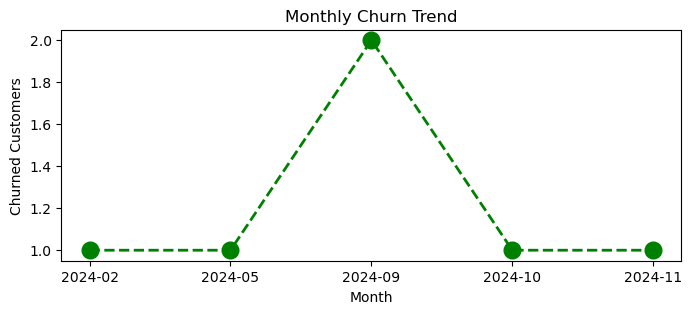

In [106]:
# 4.1 Monthly Churn Trend
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual[df_visual['churn_flag'] == 1 ].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))

plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', linestyle='dashed' , linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

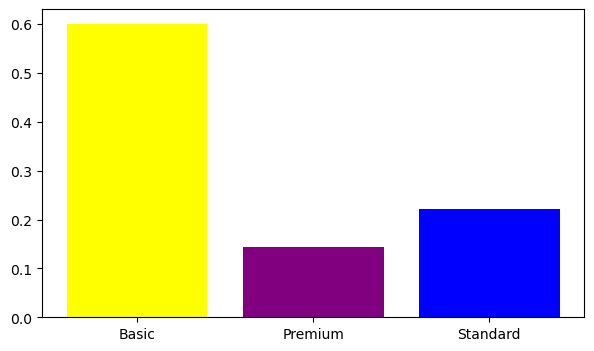

In [108]:
# 4.2 Churn by plan type

churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = ['yellow' , 'purple' , 'blue']

plt.figure(figsize=(7,4))

plt.bar(churn_plan.index, churn_plan.values, color=colors)
plt.show()

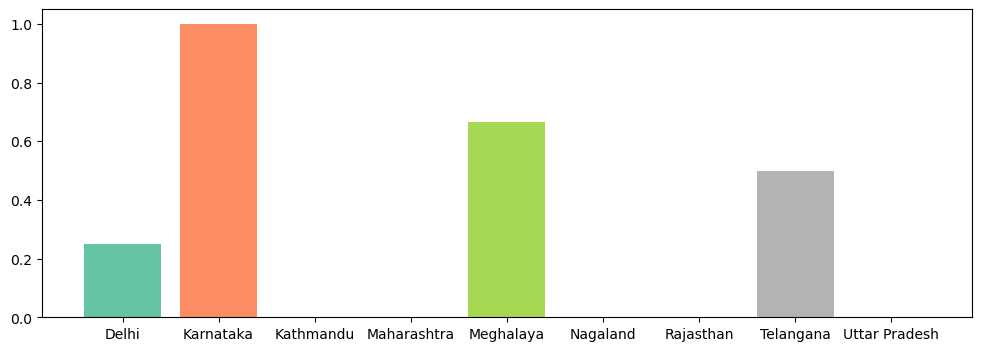

In [110]:
#4.3 churn by state
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

#colors = ['yellow' , 'purple' , 'blue']
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(12,4))

plt.bar(churn_plan.index, churn_plan.values, color=colors)
plt.show()

In [ ]:
# Visualization using Seaborn

In [111]:
# encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [114]:
df_encoded = df_visual[[ 
        'plan_type', 'contract_type',  
        'churn_score',
       'churn_flag', 
           
         'churn_risk']]

categorial_cols = [ 'plan_type', 'contract_type', 'churn_risk']  

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

C:\Users\user1\AppData\Local\Temp\ipykernel_10032\2555028342.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col] = df_encoded[col].astype('category').cat.codes
C:\Users\user1\AppData\Local\Temp\ipykernel_10032\2555028342.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col] = df_encoded[col].astype('category').cat.codes
C:\Users\user1\AppData\Local\Temp\ipykernel_10032\2555028342.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

<Axes: >

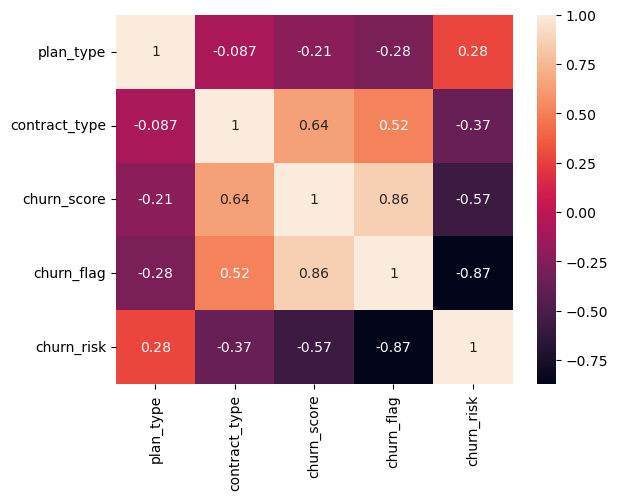

In [115]:
# Heatmap(correlation matrix)

sns.heatmap(df_encoded .corr(),annot=True )


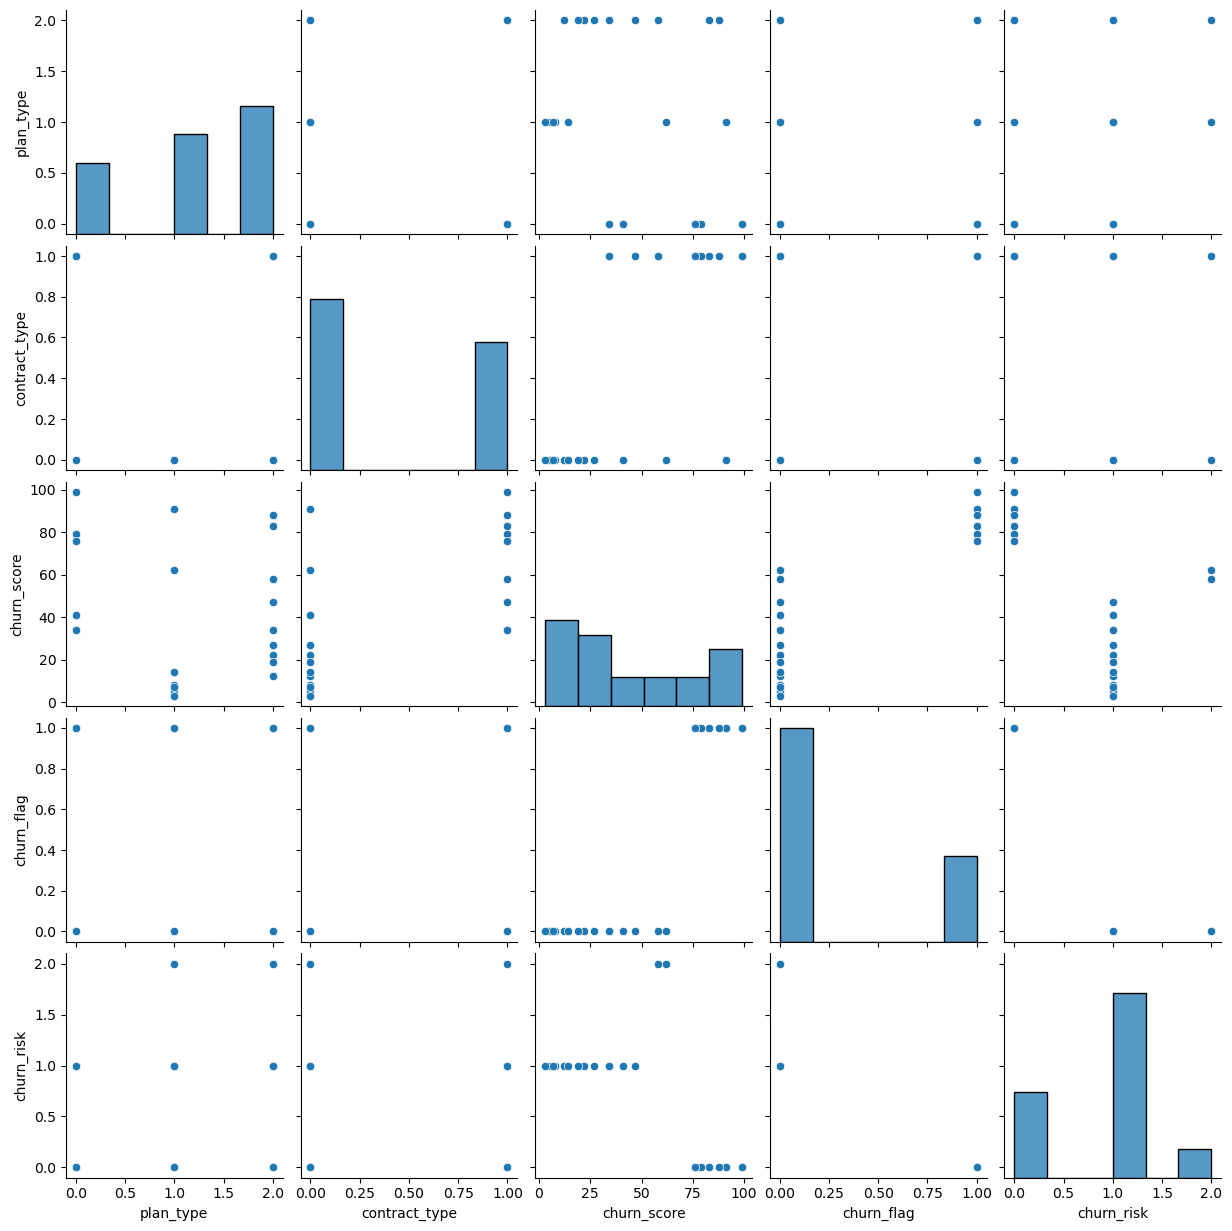

In [116]:
# pairplot
sns.pairplot(df_encoded)

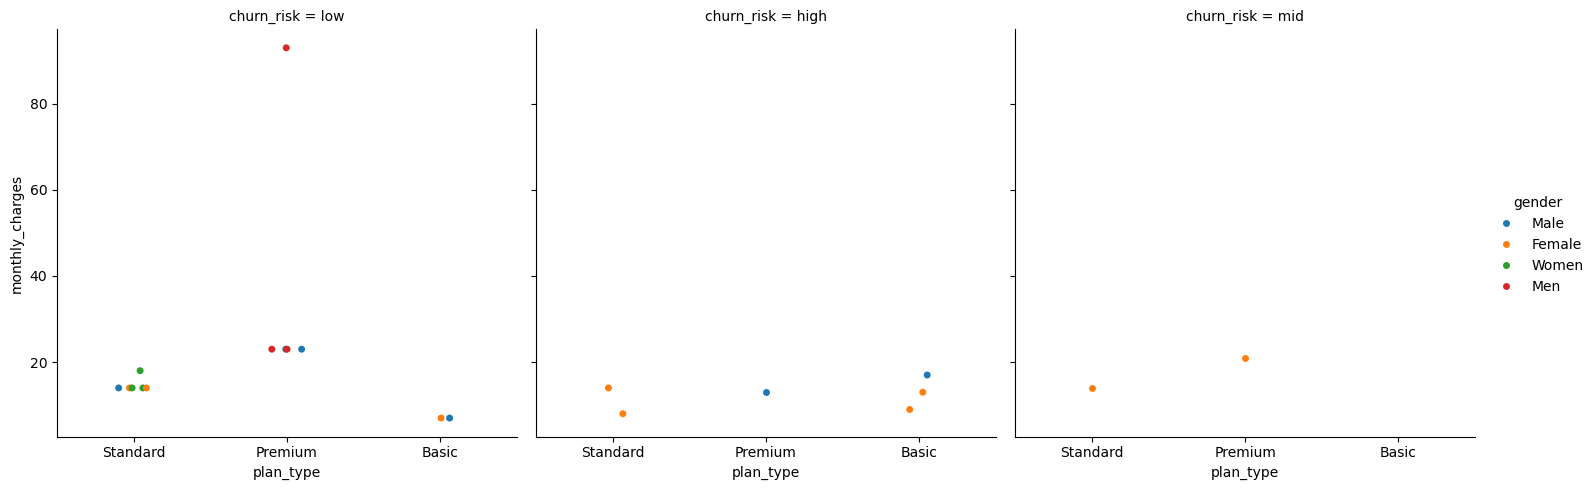

In [125]:
# catplt/Facegrid plot - Multi - dim comparison

import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk'
)

plt.show()

In [121]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [69]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,NaN,NaN,NaN,NaN,1965.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23 00:00:00,2024-08-28 00:00:00,Y,10.0,2.0,1501.0


In [ ]:
# pivot Table

In [127]:
pd.pivot_table(
    df_visual,
     index='plan_type',
    values=['monthly_charges','customerid','churn_flag'],
    aggfunc= {'monthly_charges':'sum',
              'customerid': 'nunique',
              'churn_flag': 'mean' }
     


    
) 

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91
